# Incremental Glacier Directories

OGGM distributes pre-processed glacier directories at six processing levels (L0 to L5), so that users can start a workflow from whichever stage suits their application (see the [getting started with pre-processed directories](https://tutorials.oggm.org/stable/notebooks/10minutes/preprocessed_directories.html) tutorial for an introduction).
Historically, the archive for each level was **cumulative**: the L4 tar file of a glacier contained a complete copy of the directory, including everything already published at levels 0 to 3.
This is simple but wasteful, since most of a higher-level archive duplicates data which is already available, and unchanged, at the levels below.

The **incremental** glacier directory system replaces cumulative archives with per-level **deltas** accompanied by **manifests**.
Each level ships only the files it added or changed, and the client reassembles ("layers") the levels it needs into a single glacier directory.

Contents:

1. [How delta levels and manifests work](#How-Delta-Levels-and-Manifests-Work)
2. [Converting datasets to the incremental format](#Converting-Datasets-to-the-Incremental-Format)
3. [Reading the manifests](#Reading-the-Manifests)
4. [Initialising glacier directories from incremental artifacts](#The-Client-Side:-Initialising-Glacier-Directories-from-Incremental-Artifacts)

In [ ]:
# !pip install "oggm[full] @git+https://github.com/gampnico/oggm.git@feat-ON-94-incremental-gdirs"
# !uv pip install "oggm[full] @git+https://github.com/gampnico/oggm.git@feat-ON-94-incremental-gdirs"

## TL;DR

- Incremental glacier directories replace cumulative per-level archives with **deltas and manifests**.
- Users layer the levels they need into one directory, and an assembled directory documents its origin and changes through an `L{n}.manifest.json`.
- The user-facing API is unchanged: `workflow.init_glacier_directories(..., from_prepro_level=n, prepro_base_url=...)`.
- Legacy cumulative datasets keep working exactly as before, with a single download.
- `append=True` tops up existing directories with only the missing levels.
- Existing cumulative datasets can be republished in the incremental format with `oggm.utils.compat.convert_prepro_to_deltas`.
- There will always be an extra download request at a layered entry point: starting at L4 costs two downloads per glacier rather than one (but less data is downloaded overall).

## How Delta Levels and Manifests Work

### Artifacts

With the incremental system, the archive published for a glacier at a given level is one of three kinds of artifact:

- A **delta** contains only the files which this level *added* or *changed* relative to the level below it.
  A delta is not usable on its own: its manifest lists the levels which must be layered underneath it in the `requires` field.
- A **materialisation** is a self-sufficient cumulative artifact, spanning several levels in one archive, listed in its manifest's `includes_levels`. The manifest's `requires` field is empty.
  Publishing a materialisation at a popular entry point keeps the number of downloads small: for the converted reference dataset, L3 is published as a materialisation of levels 0 to 3, so that starting a workflow at L3, L4, or L5 costs at most two downloads per glacier.
- A **standalone** artifact is the L5 "mini" run directory: a reduced directory which is sufficient on its own for running projections, without any of the lower levels.

The `kind` field itself only distinguishes `'delta'` from `'standalone'`.
A materialisation is a *functional* property rather than a separate value of the manifest's `kind` field: an artifact acts as a materialisation whenever its `includes_levels` spans several levels whilst `requires` is empty.

### The Manifest

Every artifact has one manifest per glacier, named `L{n}.manifest.json` and stored inside the glacier directory itself.
A directory assembled from several levels therefore self-documents everything which was applied to it.
The manifest fields (schema version 1) are:

| Field | Meaning |
|---|---|
| `schema_version` | Manifest schema version (currently `1`) |
| `kind` | `'delta'` or `'standalone'` |
| `rgi_id` | The glacier this manifest belongs to |
| `level` | The prepro level this artifact represents |
| `requires` | Levels which must be layered below this artifact |
| `includes_levels` | Levels whose content this artifact contains |
| `dataset_tag` | A compressed version of the base URL |
| `dataset_id` | Identifier shared by all levels of one logical dataset |
| `border` | The map border of the dataset |
| `rgi_version` | The RGI version of the dataset |
| `oggm_version` | The OGGM package version used to create the dataset |
| `created` | File creation timestamp |
| `files.added` | Regular files this level added |
| `files.updated` | Regular files this level changed |
| `zarr_groups` | `data_store.zarr` groups this level added or rewrote |

`dataset_id` is derived via `utils.dataset_id_from_tag` from an **explicit dataset tag**, never from a source URL, since one logical dataset can be served from several URLs.
The reference v1.6 dataset, for example, serves L0 to L2 from its `L1-L2_files` tree and L3 to L5 from the `L3-L5_files` spinup tree.
All of its levels must nevertheless share a single identity, because the client refuses to layer levels from different datasets on top of each other.

For the default base URL, the dataset *tag* would be `oggm_v1.6_2025.6_elev_bands_w5e5`.
The `dataset_id` hashes the tag, the RGI version, and the border.

### How the Client Assembles a Directory

When you request a glacier at level *n* with `workflow.init_glacier_directories(..., from_prepro_level=n)`, the client:

1. Downloads the level-*n* bundle and peeks at the glacier's manifest inside it, without extracting the whole bundle.
2. Compares the manifest's `requires` against its `includes_levels`, and iteratively downloads whichever required level is not yet covered, highest missing level first.
3. Extracts the collected archives in ascending level order into one glacier directory.
4. Finalises the merged directory:
  - The root metadata of the zarr data store is recreated and re-consolidated, since deltas ship changed `data_store.zarr/<group>` subtrees only, never the store's root metadata, which would be stale after layering.
  - The applied manifests are checked for compatibility.
    They must share one `dataset_id`, every `requires` must be covered, and the resulting levels must be contiguous.
    Any violation raises an `InvalidWorkflowError`.

For the converted reference dataset, the resulting download counts per glacier are:

- L3: one fetch (the L0 to L3 materialisation).
- L4: two fetches (the L4 delta plus the L3 materialisation it requires).
- L5: one fetch (standalone).

### Backwards Compatibility

A bundle without a manifest is recognised as a **legacy** cumulative artifact and handled exactly as before: a single download, no layering.
Old published datasets therefore keep working unchanged, with the same API calls.

## Setup

The usual OGGM initialisation.

In [ ]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from oggm import cfg, utils, workflow
from oggm.utils import compat, _downloads

cfg.initialize(logging_level="WARNING")
cfg.PARAMS["use_multiprocessing"] = True

base_dir = utils.gettempdir(dirname="OGGM-incremental-gdirs", reset=True)
base_dir

2026-09-16 13:14:14: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-09-16 13:14:14: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-09-16 13:14:14: oggm.cfg: Multiprocessing: using all available processors (N=22)
2026-09-16 13:14:14: oggm.cfg: Multiprocessing switched ON after user settings.


'/tmp/OGGM/OGGM-incremental-gdirs'

## Converting Datasets to the Incremental Format

The OGGM cluster currently serves the published pre-processed directories in the old, cumulative format.
To obtain incremental artifacts we therefore convert a small subset of the published reference dataset locally with `oggm.utils.compat.convert_prepro_to_deltas`.
This is the same procedure a data provider would run once on the cluster to republish an existing dataset in the incremental format.

The converter downloads each available level of the requested glaciers into isolated working directories, computes content hashes (`utils.snapshot_gdir_state`) to diff successive levels, writes the per-level manifests (`utils.write_level_manifest`), and emits a delta-format server tree `{output_dir}/RGI{version}/b_{border}/L{n}/{region}/{bundle}.tar`, which is the same directory layout the download URLs follow.

We use the two OGGM reference test glaciers: Hintereisferner in the Austrian Alps, and a glacier in the Alaska region, at map border 80.

Two details of the call matter:

- **Per-level base URLs.** The reference v1.6 dataset spans two source trees: levels 0 to 2 live under `L1-L2_files`, whilst levels 3 to 5 live under the `L3-L5_files` spinup tree (which is OGGM's `DEFAULT_BASE_URL`).
  The converter therefore takes a mapping of the level onto the base URL rather than a single URL.
- **The dataset tag.** Because one logical dataset can span several source URLs, its identity must come from an explicit, human-chosen tag.
  The tag is hashed together with the border and the RGI version into the `dataset_id` which all manifests of the dataset share.

In [ ]:
rgi_ids = [
    "RGI60-11.00897",  # Hintereisferner (Austrian Alps)
    "RGI60-01.16195",  # Alaska region
]

# Levels 0-2 and levels 3-5 of the reference dataset live in two different source trees on the server
L12_BASE_URL = (
    "https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/"
    "L1-L2_files/2025.6/elev_bands/"
)
L35_BASE_URL = utils.DEFAULT_BASE_URL
base_urls = {
    0: L12_BASE_URL,
    1: L12_BASE_URL,
    2: L12_BASE_URL,
    3: L35_BASE_URL,
    4: L35_BASE_URL,
    5: L35_BASE_URL,
}

dataset_tag = "oggm_v1.6_2025.6_elev_bands_w5e5"

output_dir = os.path.join(base_dir, "delta_server")
out_root = compat.convert_prepro_to_deltas(
    rgi_ids,
    base_urls,
    border=80,
    rgi_version="62",
    workdir=os.path.join(base_dir, "conversion_workdir"),
    output_dir=output_dir,
    dataset_tag=dataset_tag,
    convert_to_zarr=True,  # This can take a very long time when set to True!
)
out_root

2026-09-16 13:14:14: oggm.workflow: init_glacier_directories from prepro level 0 on 2 glaciers.
2026-09-16 13:14:14: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers
2026-09-16 13:14:15: oggm.workflow: init_glacier_directories from prepro level 1 on 2 glaciers.
2026-09-16 13:14:15: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers
2026-09-16 13:14:16: oggm.workflow: init_glacier_directories from prepro level 2 on 2 glaciers.
2026-09-16 13:14:16: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers
2026-09-16 13:14:17: oggm.workflow: init_glacier_directories from prepro level 3 on 2 glaciers.
2026-09-16 13:14:17: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers
2026-09-16 13:14:20: oggm.workflow: init_glacier_directories from prepro level 4 on 2 glaciers.
2026-09-16 13:14:20: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers
2026-09-16 13:14:22: oggm.workflow: init_glacier_directories from prep

'/tmp/OGGM/OGGM-incremental-gdirs/delta_server/RGI62/b_080'

The converter produced a complete delta-format server tree.
Listing it shows the effect of the incremental format on artifact sizes: the L1 and L2 deltas, and especially the L4 delta, are smaller than the materialisations, because they only carry what their level changed.
Each `.tar` file remains a *bundle*: it groups the per-glacier `.tar.gz` archives of up to 100 glaciers which share the same ID prefix.

In [ ]:
for root, dirs, files in sorted(os.walk(output_dir)):
    for file in sorted(files):
        path = os.path.join(root, file)
        rel = os.path.relpath(path, output_dir)
        print(f"{os.path.getsize(path) / 1024 ** 1:7.1f} KiB  {rel}")

   10.0 KiB  RGI62/b_080/L0/RGI60-01/RGI60-01.161.tar
   20.0 KiB  RGI62/b_080/L0/RGI60-11/RGI60-11.008.tar
  170.0 KiB  RGI62/b_080/L1/RGI60-01/RGI60-01.161.tar
  170.0 KiB  RGI62/b_080/L1/RGI60-11/RGI60-11.008.tar
  320.0 KiB  RGI62/b_080/L2/RGI60-01/RGI60-01.161.tar
  330.0 KiB  RGI62/b_080/L2/RGI60-11/RGI60-11.008.tar
  520.0 KiB  RGI62/b_080/L3/RGI60-01/RGI60-01.161.tar
  540.0 KiB  RGI62/b_080/L3/RGI60-11/RGI60-11.008.tar
  210.0 KiB  RGI62/b_080/L4/RGI60-01/RGI60-01.161.tar
  480.0 KiB  RGI62/b_080/L4/RGI60-11/RGI60-11.008.tar
  240.0 KiB  RGI62/b_080/L5/RGI60-01/RGI60-01.161.tar
  280.0 KiB  RGI62/b_080/L5/RGI60-11/RGI60-11.008.tar


## Reading the Manifests

The manifest of a glacier travels *inside* its archive, so there are two places to read it from:

- **Inside a bundle tar**, with `workflow._peek_level_manifest`, before deciding what else to download.
  It reads the member archive directly, without extracting the bundle.
- **Inside an assembled glacier directory**, where every applied level has left its `L{n}.manifest.json` (see below).

Here is Hintereisferner's L4 manifest inside the bundle we just produced:

In [ ]:
rid = rgi_ids[0]
region = rid[:-6]  # 'RGI60-11'
bundle = f"{region}.{rid[-5:-2]}"  # 'RGI60-11.008', the 100-glacier bundle


def bundle_path(level):
    return os.path.join(out_root, f"L{level}", region, f"{bundle}.tar")


manifest_l4 = workflow._peek_level_manifest(bundle_path(4), rid, level=4)
print(json.dumps(manifest_l4, indent=2))

{
  "schema_version": 1,
  "kind": "delta",
  "rgi_id": "RGI60-11.00897",
  "level": 4,
  "requires": [
    0,
    1,
    2,
    3
  ],
  "includes_levels": [
    4
  ],
  "dataset_tag": "oggm_v1.6_2025.6_elev_bands_w5e5",
  "dataset_id": "1430a5349f9ba2dff617cc264e34a03595caafe0",
  "border": 80,
  "rgi_version": "62",
  "oggm_version": "1.6.4.dev137+g0a11f0703.d20260916",
  "created": "2026-09-16T12:14:21.748190+00:00",
  "files": {
    "added": [
      "fl_diagnostics_historical.nc",
      "fl_diagnostics_spinup_historical.nc",
      "model_diagnostics_historical.nc",
      "model_diagnostics_spinup_historical.nc",
      "model_geometry_historical.nc",
      "model_geometry_spinup_historical.nc"
    ],
    "updated": [
      "dem.tif",
      "diagnostics.json",
      "intersects.tar.gz",
      "log.txt",
      "mb_calib.json",
      "outlines.tar.gz"
    ]
  },
  "zarr_groups": [
    "inversion_flowlines",
    "inversion_input",
    "inversion_output",
    "model_flowlines_dyn_melt_

This manifest describes a **delta**:

- `requires` tells the client that levels 0 to 3 must sit below it.
- `includes_levels` says the archive only carries level 4's changes.
- `files.added` and `files.updated` list exactly what level 4 contributed, here the model output and the diagnostics.
- `zarr_groups` lists the `data_store.zarr` groups this level added or rewrote.
  The published 2025.6 source predates the zarr data store, so these groups come from the pickle objects rewritten by `convert_to_zarr=True`.

Compare this with the L3 and L5 manifests of the same glacier:

In [ ]:
for level in (3, 5):
    m = workflow._peek_level_manifest(bundle_path(level), rgi_id=rid, level=level)
    print(
        f"L{level}: kind={m['kind']!r}, "
        f"includes_levels={m['includes_levels']}, "
        f"requires={m['requires']}"
    )

L3: kind='delta', includes_levels=[0, 1, 2, 3], requires=[]
L5: kind='standalone', includes_levels=[5], requires=[]


L3 is the **materialisation**: it includes levels 0 to 3 and requires nothing, so it is a valid starting point on its own.
L5 is the **standalone** mini directory.

The `dataset_id` in every manifest is reproducible from the tag we passed to the converter.
This is how the client verifies that the levels it is about to layer belong to the same logical dataset:

In [ ]:
utils.dataset_id_from_tag(dataset_tag, 80, "62") == manifest_l4["dataset_id"]

True

## The Client Side: Initialising Glacier Directories from Incremental Artifacts

Against a real server, nothing about the user-facing workflow changes: you call `workflow.init_glacier_directories` with a base URL exactly as you always have, and the layering happens transparently.

Since our converted tree lives on the local disk and OGGM's downloader only supports HTTP, we simulate a server: we temporarily replace OGGM's `file_downloader` with a small function which resolves URLs under a placeholder base URL to files in the converted tree, and records every request so we can count the fetches.
Requests for anything else (e.g. RGI support files) are passed through to the real downloader.

We also set `cfg.PARAMS['has_internet'] = False` for the duration of the demonstration, because `init_glacier_directories` otherwise validates the base URL with a real HTTP request, and our placeholder URL does not exist.
Both changes are undone at the end of the notebook.

In [ ]:
DEMO_BASE_URL = "https://demo.invalid/gdirs/"
fetch_log = []
_original_file_downloader = _downloads.file_downloader


def local_file_downloader(www_path, **kwargs):
    """Serve 'downloads' from the local delta tree, recording each request."""
    if not www_path.startswith(DEMO_BASE_URL):
        return _original_file_downloader(www_path, **kwargs)
    fetch_log.append(www_path)
    local = os.path.join(output_dir, www_path[len(DEMO_BASE_URL) :])
    return local if os.path.isfile(local) else None


_downloads.file_downloader = local_file_downloader
# Forget the bundle-layout probing cached during the conversion downloads
_downloads._prepro_bundle_format.clear()
# Keep OGGM from probing the (nonexistent) demo server over real HTTP
cfg.PARAMS["has_internet"] = False

2026-09-16 13:14:24: oggm.cfg: PARAMS['has_internet'] changed from `True` to `False`.


### Starting a Workflow at Level 4

We now initialise both glaciers at level 4.
For each glacier the client should:

1. Download the L4 delta.
2. Read `requires: [0, 1, 2, 3]` from its manifest.
3. Notice that the L3 materialisation covers all of it, and stop after a second fetch.

In [ ]:
cfg.PATHS["working_dir"] = utils.mkdir(os.path.join(base_dir, "wd_l4"))

fetch_log.clear()
gdirs = workflow.init_glacier_directories(
    rgi_ids,
    from_prepro_level=4,
    prepro_border=80,
    prepro_base_url=DEMO_BASE_URL,
)

print(f"{len(fetch_log)} fetches for {len(gdirs)} glaciers at L4:")
for url in fetch_log:
    print("  ", url[len(DEMO_BASE_URL) :])

2026-09-16 13:14:24: oggm.workflow: init_glacier_directories from prepro level 4 on 2 glaciers.
2026-09-16 13:14:24: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers


0 fetches for 2 glaciers at L4:


The assembled glacier directory carries the manifests of both artifacts which were layered into it, so it self-documents its own provenance:

In [ ]:
gdir = gdirs[0]
sorted(f for f in os.listdir(gdir.dir) if f.endswith(".manifest.json"))

['L3.manifest.json', 'L4.manifest.json']

In [ ]:
with open(os.path.join(gdir.dir, "L4.manifest.json")) as f:
    manifest = json.load(f)
{k: manifest[k] for k in ("kind", "level", "includes_levels", "requires", "dataset_id")}

{'kind': 'delta',
 'level': 4,
 'includes_levels': [4],
 'requires': [0, 1, 2, 3],
 'dataset_id': '1430a5349f9ba2dff617cc264e34a03595caafe0'}

To convince ourselves that the layering produced a fully functional directory, we read data contributed by three different levels:

- The gridded topography (L1 and L2, shipped inside the L3 materialisation).
- The calibrated mass-balance parameters (L3).
- The dynamical model flowlines, which are only in the L4 delta.

Note that `read_store` reads the zarr data store where it exists, and otherwise falls back to the pickle files with a warning.

In [ ]:
with xr.open_dataset(gdir.get_filepath("gridded_data")) as ds:
    print("gridded_data variables:", ", ".join(ds.data_vars))

print("calibrated melt factor:", gdir.read_json("mb_calib")["melt_f"])

fls = gdir.read_store("model_flowlines")
print(f"model_flowlines: {len(fls)} flowline(s), {fls[-1].nx} grid points")

gridded_data variables: topo, topo_smoothed, topo_valid_mask, glacier_mask, glacier_ext
calibrated melt factor: 4.906856791650656
model_flowlines: 1 flowline(s), 100 grid points


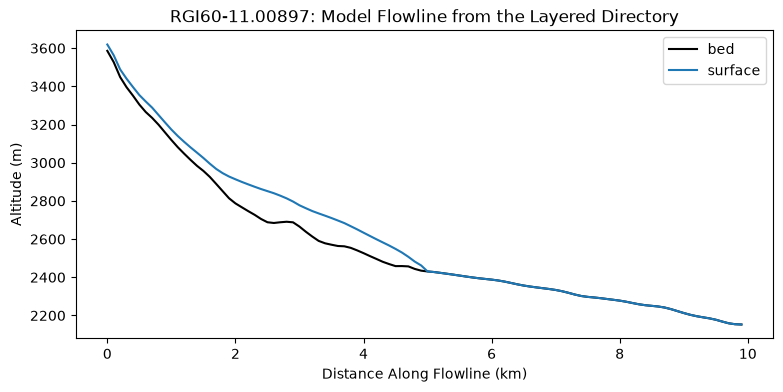

In [ ]:
fl = fls[-1]
x = np.arange(fl.nx) * fl.dx_meter / 1000
plt.figure(figsize=(9, 4))
plt.plot(x, fl.bed_h, "k", label="bed")
plt.plot(x, fl.surface_h, "C0", label="surface")
plt.xlabel("Distance Along Flowline (km)")
plt.ylabel("Altitude (m)")
plt.title(f"{gdir.rgi_id}: Model Flowline from the Layered Directory")
plt.legend();

### Topping Up an Existing Directory with `append=True`

A common situation: you started your analysis from the L3 materialisation, and later decide you also need level 4.
With cumulative archives this meant re-downloading everything.
With the incremental system, `init_glacier_directories(..., append=True)` layers *only the missing levels* onto the directories already in your working directory.
The existing manifests tell the client which levels are already covered.

First, a fresh working directory initialised at L3:

In [ ]:
cfg.PATHS["working_dir"] = utils.mkdir(os.path.join(base_dir, "wd_append"))

fetch_log.clear()
gdirs = workflow.init_glacier_directories(
    rgi_ids,
    from_prepro_level=3,
    prepro_border=80,
    prepro_base_url=DEMO_BASE_URL,
)

print(f"{len(fetch_log)} fetches for {len(gdirs)} glaciers at L3:")
for url in fetch_log:
    print("  ", url[len(DEMO_BASE_URL) :])

2026-09-16 13:14:25: oggm.workflow: init_glacier_directories from prepro level 3 on 2 glaciers.
2026-09-16 13:14:25: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers


0 fetches for 2 glaciers at L3:


Now the top-up to L4.
Only the L4 delta of each glacier is fetched, since the levels below come from the directories we already have:

In [ ]:
fetch_log.clear()
gdirs = workflow.init_glacier_directories(
    rgi_ids,
    from_prepro_level=4,
    prepro_border=80,
    prepro_base_url=DEMO_BASE_URL,
    append=True,
)

print(f"{len(fetch_log)} fetches for the L3 -> L4 top-up:")
for url in fetch_log:
    print("  ", url[len(DEMO_BASE_URL) :])

sorted(f for f in os.listdir(gdirs[0].dir) if f.endswith(".manifest.json"))

2026-09-16 13:14:25: oggm.workflow: init_glacier_directories from prepro level 4 on 2 glaciers.
2026-09-16 13:14:25: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers


0 fetches for the L3 -> L4 top-up:


['L3.manifest.json', 'L4.manifest.json']

### Standalone Level 5

The L5 mini directories are self-sufficient by design, so requesting them is always a single fetch per glacier:

In [ ]:
cfg.PATHS["working_dir"] = utils.mkdir(os.path.join(base_dir, "wd_l5"))

fetch_log.clear()
gdirs = workflow.init_glacier_directories(
    rgi_ids,
    from_prepro_level=5,
    prepro_border=80,
    prepro_base_url=DEMO_BASE_URL,
)

print(f"{len(fetch_log)} fetches for {len(gdirs)} glaciers at L5:")
for url in fetch_log:
    print("  ", url[len(DEMO_BASE_URL) :])

2026-09-16 13:14:26: oggm.workflow: init_glacier_directories from prepro level 5 on 2 glaciers.
2026-09-16 13:14:26: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers


0 fetches for 2 glaciers at L5:


Finally, we restore the real downloader:

In [ ]:
_downloads.file_downloader = _original_file_downloader
_downloads._prepro_bundle_format.clear()
cfg.PARAMS["has_internet"] = True

2026-09-16 13:14:26: oggm.cfg: PARAMS['has_internet'] changed from `False` to `True`.


## Summary

- Incremental glacier directories replace cumulative per-level archives with **deltas and manifests**.
  Users layer the levels they need into one directory, and an assembled directory documents its own provenance through an `L{n}.manifest.json`.
- The user-facing API is unchanged: `workflow.init_glacier_directories(..., from_prepro_level=n, prepro_base_url=...)`.
- Legacy (manifest-less) datasets keep working exactly as before, with a single cumulative download.
- `append=True` tops up existing directories with only the missing levels.
- Existing cumulative datasets can be republished in the incremental format with `oggm.utils.compat.convert_prepro_to_deltas`.
- The trade-off is one extra request at a layered entry point, which is only worth it where the deltas are appreciably smaller than the levels below them.
  For the Alaska glacier above, the L4 delta is 210 KiB against 520 KiB for the L3 materialisation.
- The downloader override used in this notebook was only needed because our converted tree lives on the local disk.